Dataset Loaded Successfully!
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None


Missing Values:


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0



Features Used: ['Annual Income (k$)', 'Spending Score (1-100)']


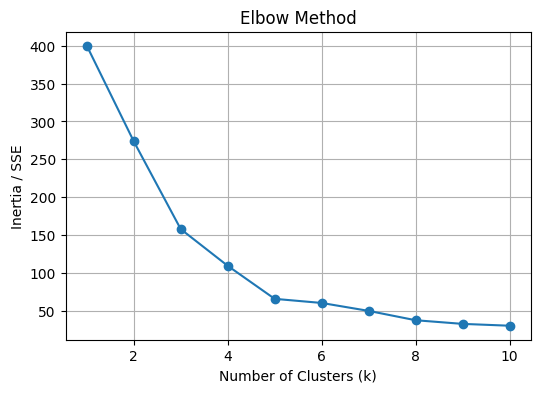

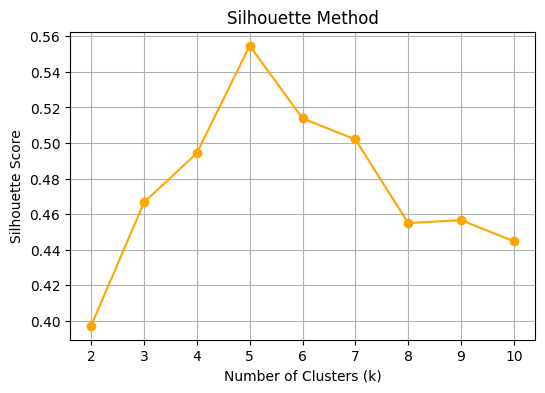


Cluster Counts:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

Cluster Centers (Original Values):


,Annual Income (k$),Spending Score (1-100),Cluster
0,55.30,49.52,0
1,86.54,82.13,1
2,25.73,79.36,2
3,88.20,17.11,3
4,26.30,20.91,4


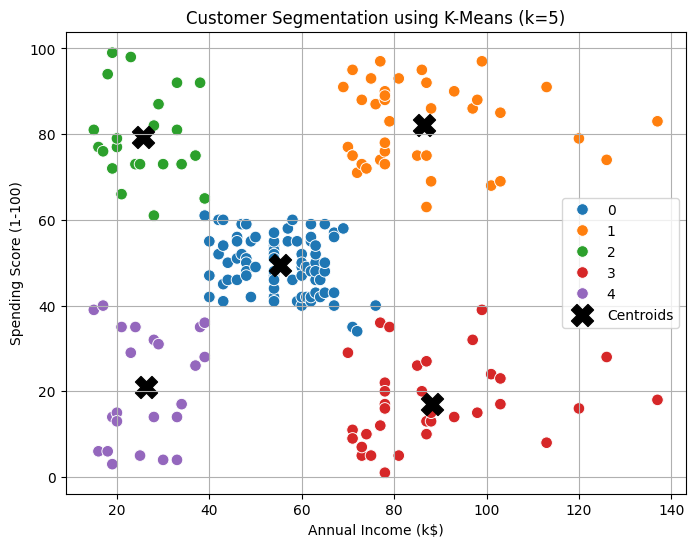

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------
# 1. Load the dataset
# ---------------------------------------
df = pd.read_csv("Mall_Customers.csv")  # UPDATE PATH IF NEEDED
print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
display(df.head())

# ---------------------------------------
# 2. Check info and missing values
# ---------------------------------------
print("\nDataset Info:")
display(df.info())
print("\nMissing Values:")
display(df.isnull().sum())

# ---------------------------------------
# 3. Select features for clustering
# Using Income & Spending Score
# ---------------------------------------
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features]

print("\nFeatures Used:", features)

# ---------------------------------------
# 4. Standardize the data
# ---------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------
# 5. Elbow Method to choose k
# ---------------------------------------
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia / SSE")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

# ---------------------------------------
# 6. Silhouette Scores
# ---------------------------------------
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(range(2, 11), sil_scores, marker='o', color="orange")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.grid(True)
plt.show()

# ---------------------------------------
# 7. Apply KMeans (Choose k=5 by elbow)
# ---------------------------------------
k_final = 5
kmeans = KMeans(n_clusters=k_final, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = cluster_labels
print("\nCluster Counts:")
print(df["Cluster"].value_counts())

# ---------------------------------------
# 8. Cluster Centers in original units
# ---------------------------------------
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers_original, columns=features)
centers_df["Cluster"] = range(k_final)

print("\nCluster Centers (Original Values):")
display(centers_df.round(2))

# ---------------------------------------
# 9. Visualization of Clusters
# ---------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=70
)

# Show cluster centers
plt.scatter(
    centers_df["Annual Income (k$)"],
    centers_df["Spending Score (1-100)"],
    s=250,
    c="black",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means (k=5)")
plt.legend()
plt.grid(True)
plt.show()




In [1]:
from google.colab import files
uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers.csv
